In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('amazon_delivery_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (6879, 22)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Vehicle,Area,Delivery_Time,Category,dist_km,pickup_wait,dist_km_minmax,Delivery_Time_minmax,Agent_Age_z,Agent_Rating_z
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,...,motorcycle,Urban,120.0,Clothing,3.025149,15.0,0.079986,0.423077,1.283354,0.862483
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,...,scooter,Metropolitian,165.0,Electronics,20.183530,5.0,0.959704,0.596154,0.766158,-0.413779
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,...,motorcycle,Urban,130.0,Sports,1.552758,15.0,0.004496,0.461538,-1.130227,-0.732844
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,...,motorcycle,Metropolitian,105.0,Cosmetics,7.790401,10.0,0.324303,0.365385,1.455752,0.224352
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,...,scooter,Metropolitian,150.0,Toys,6.210138,15.0,0.243282,0.538462,0.421360,-0.094713


In [2]:
num_cols = ['Delivery_Time', 'dist_km', 'Agent_Age', 'Agent_Rating', 'pickup_wait']

print("Descriptive statistics:\n")
print(df[num_cols].describe().round(2))

print("\nSkewness:\n")
print(df[num_cols].skew().round(2))

print("\nMode of Delivery_Time:", df['Delivery_Time'].mode()[0])

Descriptive statistics:

       Delivery_Time  dist_km  Agent_Age  Agent_Rating  pickup_wait
count        6878.00  6879.00    6879.00       6879.00      6879.00
mean          126.19     9.68      29.56          4.63         9.85
std            52.09     5.59       5.80          0.31         4.09
min            10.00     1.47      20.00          2.50         5.00
25%            90.00     4.66      25.00          4.50         5.00
50%           125.00     9.18      30.00          4.70        10.00
75%           160.00    13.62      35.00          4.80        15.00
max           270.00    20.97      39.00          5.00        15.00

Skewness:

Delivery_Time    0.17
dist_km          0.33
Agent_Age       -0.02
Agent_Rating    -1.74
pickup_wait      0.06
dtype: float64

Mode of Delivery_Time: 135.0


In [3]:
corr = df[num_cols].corr()
print(corr.round(2))

               Delivery_Time  dist_km  Agent_Age  Agent_Rating  pickup_wait
Delivery_Time           1.00     0.30       0.26         -0.32        -0.01
dist_km                 0.30     1.00      -0.00         -0.11         0.00
Agent_Age               0.26    -0.00       1.00         -0.11        -0.02
Agent_Rating           -0.32    -0.11      -0.11          1.00         0.01
pickup_wait            -0.01     0.00      -0.02          0.01         1.00


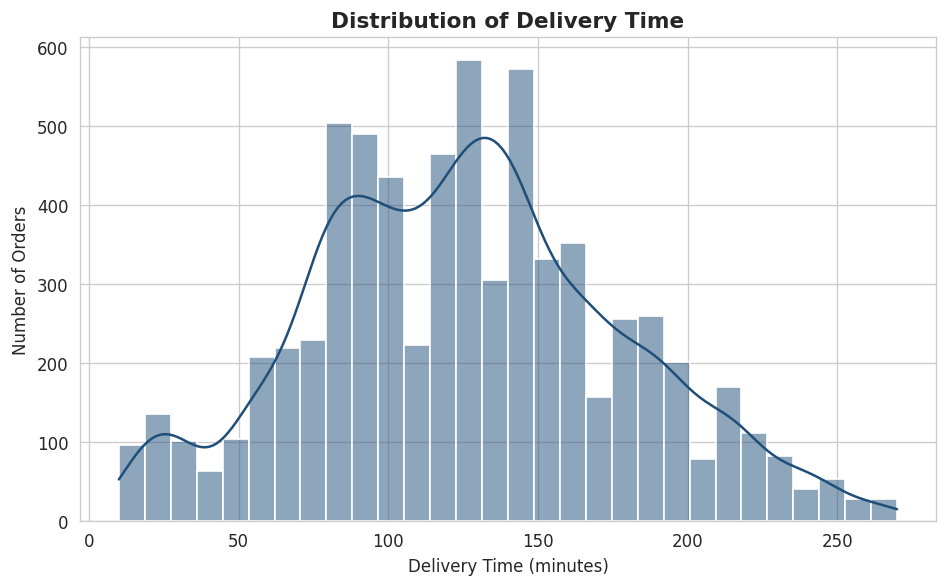

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Delivery_Time'], bins=30, kde=True, color="#1F4E79")
plt.title('Distribution of Delivery Time', fontsize=13, fontweight='bold')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart1_histogram.png', dpi=200)
plt.show()

/tmp/ipykernel_4134/2132803843.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic', y='Delivery_Time', data=df, order=order, palette="Blues")


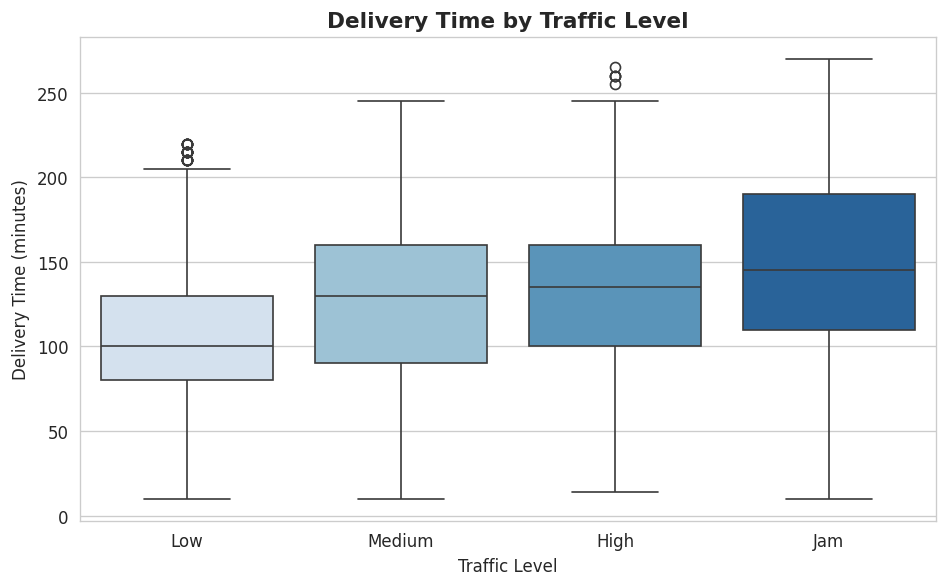

In [5]:
plt.figure(figsize=(8, 5))
order = ['Low', 'Medium', 'High', 'Jam']
sns.boxplot(x='Traffic', y='Delivery_Time', data=df, order=order, palette="Blues")
plt.title('Delivery Time by Traffic Level', fontsize=13, fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.savefig('chart2_boxplot_traffic.png', dpi=200)
plt.show()

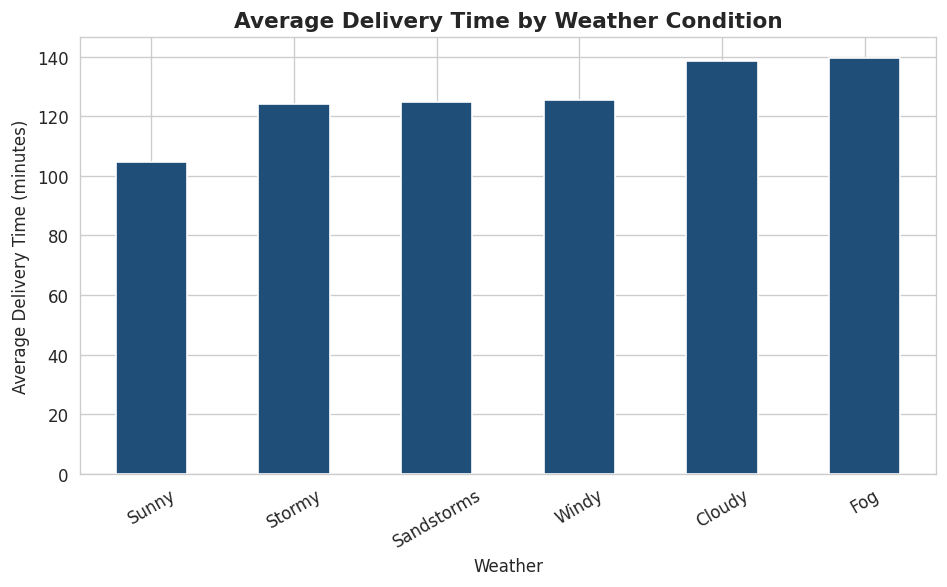

In [6]:
plt.figure(figsize=(8, 5))
weather_avg = df.groupby('Weather')['Delivery_Time'].mean().sort_values()
weather_avg.plot(kind='bar', color="#1F4E79")
plt.title('Average Delivery Time by Weather Condition', fontsize=13, fontweight='bold')
plt.xlabel('Weather')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart3_bar_weather.png', dpi=200)
plt.show()

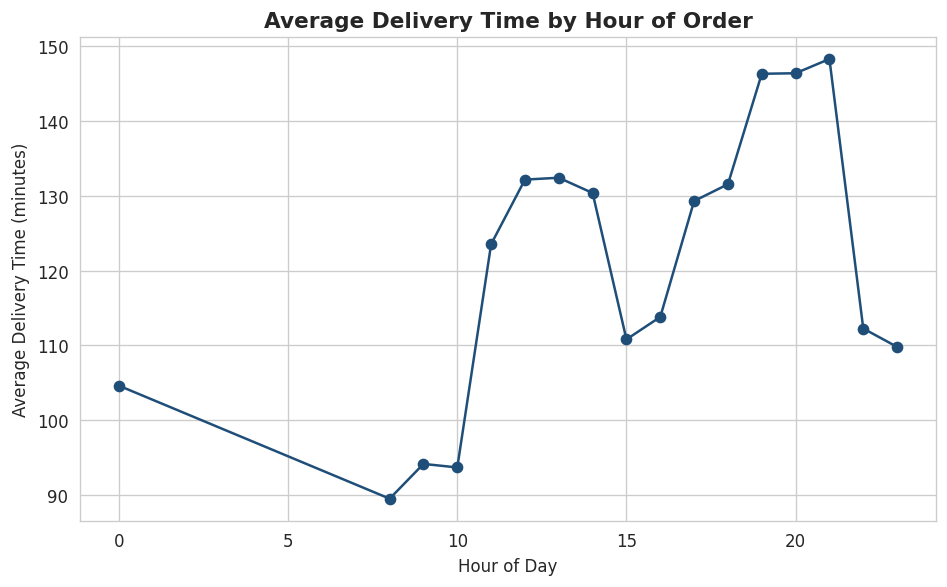

In [7]:
df['order_dt'] = pd.to_datetime(df['Order_Date'] + ' ' + df['Order_Time'])
df['hour'] = df['order_dt'].dt.hour

plt.figure(figsize=(8, 5))
hourly_avg = df.groupby('hour')['Delivery_Time'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color="#1F4E79")
plt.title('Average Delivery Time by Hour of Order', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delivery Time (minutes)')
plt.tight_layout()
plt.savefig('chart4_line_hourly.png', dpi=200)
plt.show()

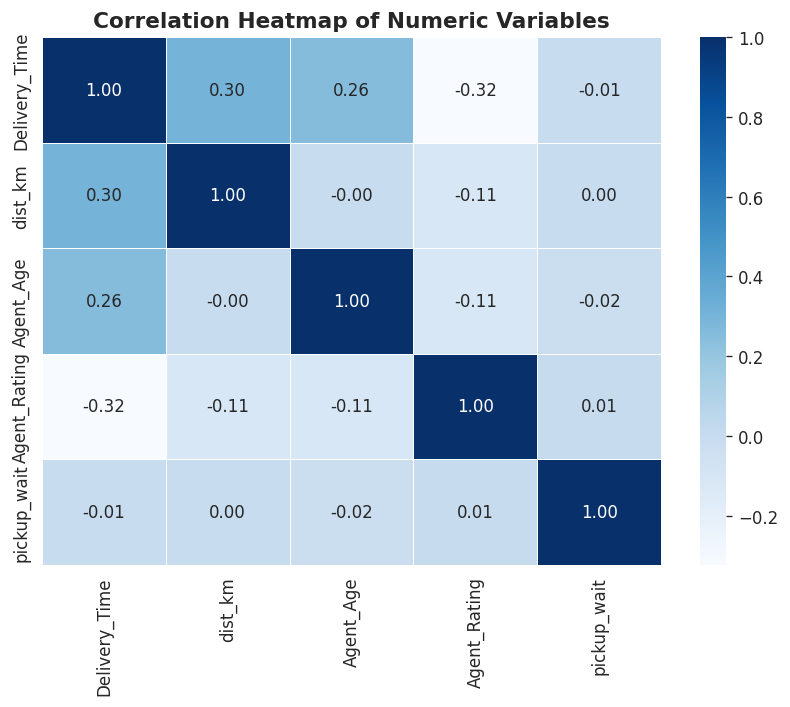

In [8]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=200)
plt.show()

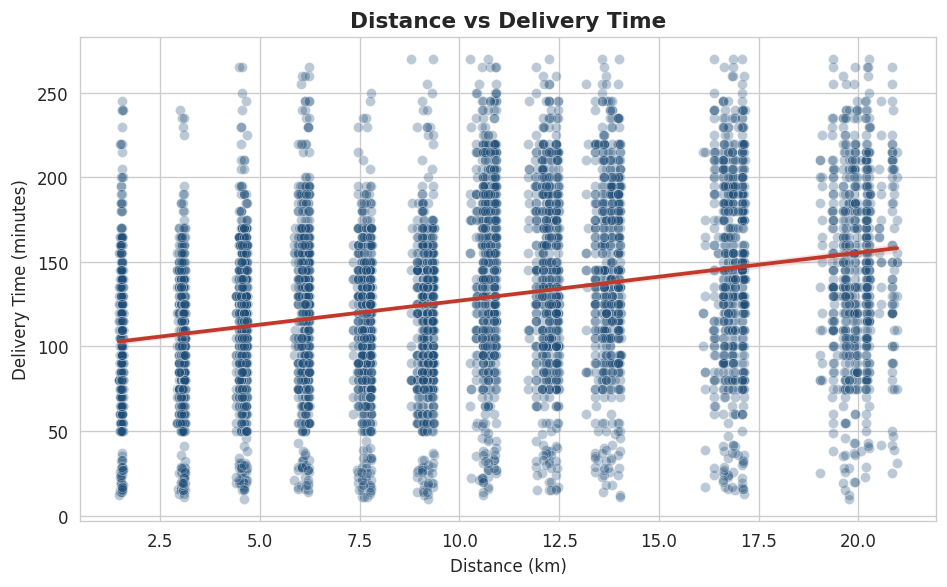

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='dist_km', y='Delivery_Time', data=df, alpha=0.3, color="#1F4E79")
sns.regplot(x='dist_km', y='Delivery_Time', data=df, scatter=False, color="#C0392B")
plt.title('Distance vs Delivery Time', fontsize=13, fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.savefig('chart6_scatter_distance.png', dpi=200)
plt.show()

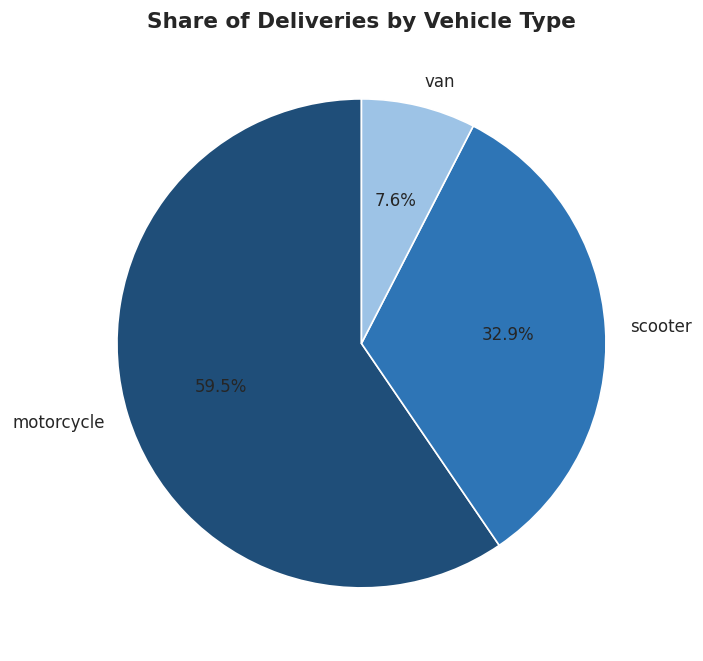

In [10]:
plt.figure(figsize=(6, 6))
vehicle_counts = df['Vehicle'].value_counts()
colors = ["#1F4E79", "#2E75B6", "#9DC3E6", "#C0392B"]
plt.pie(vehicle_counts, labels=vehicle_counts.index, autopct='%1.1f%%',
        colors=colors[:len(vehicle_counts)], startangle=90)
plt.title('Share of Deliveries by Vehicle Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_pie_vehicle.png', dpi=200)
plt.show()

<Figure size 1080x600 with 0 Axes>

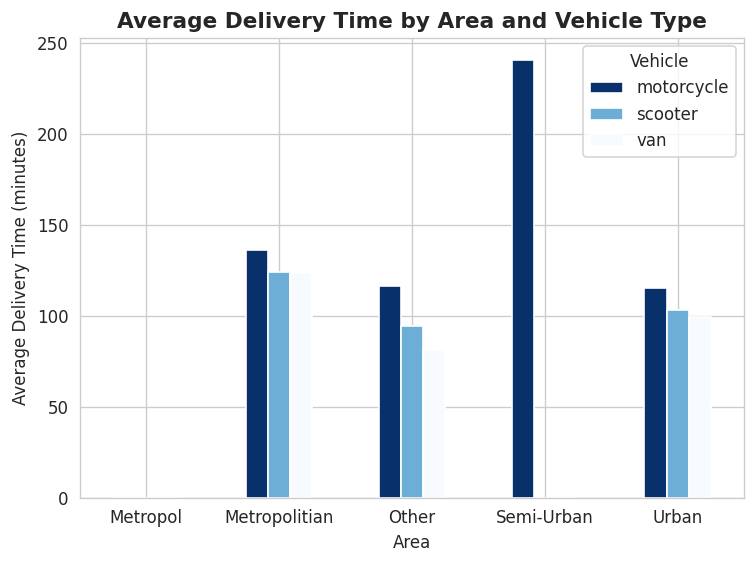

In [11]:
plt.figure(figsize=(9, 5))
pivot = df.groupby(['Area', 'Vehicle'])['Delivery_Time'].mean().unstack()
pivot.plot(kind='bar', colormap='Blues_r')
plt.title('Average Delivery Time by Area and Vehicle Type', fontsize=13, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.legend(title='Vehicle')
plt.tight_layout()
plt.savefig('chart8_grouped_bar_area_vehicle.png', dpi=200)
plt.show()

In [12]:
from google.colab import files
import os

for f in sorted(os.listdir('.')):
    if f.startswith('chart') and f.endswith('.png'):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>